# 📝 Modelo TCN — Predicción de Tráfico M-30

**Fase CRISP-DM:** Modeling
**Proyecto:** Predicción de tráfico en carretera mediante análisis de series temporales (M30)

## Objetivo

Este notebook implementa un **Temporal Convolutional Network (TCN)** para la predicción multivariante de la intensidad de tráfico en los 4 sensores de la M-30.

El TCN utiliza **convoluciones dilatadas causales** apiladas en bloques residuales. A diferencia de los modelos recurrentes (LSTM), el TCN es paralelizable y evita el problema del gradiente desvaneciente, capturando dependencias temporales a largo plazo de forma eficiente.

## Estructura del Experimento

Se entrenan **6 modelos** (uno por combinación de ventana de entrada × horizonte de predicción). Cada modelo predice simultáneamente las **4 intensidades** (multi-output).

| Ventana entrada | Horizonte salida |
|:---:|:---:|
| 48 h | 1 h |
| 48 h | 24 h |
| 48 h | 168 h |
| 168 h | 1 h |
| 168 h | 24 h |
| 168 h | 168 h |

Las métricas finales (MAE, RMSE) se reportan en unidades físicas (vehículos/hora) aplicando la transformación inversa del `StandardScaler`.

In [1]:
%cd ..

c:\Users\ronal\Documents\GitHub\TFM\notebooks


In [2]:
##!pip install nbformat

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error
import os
import warnings
import nbformat
warnings.filterwarnings('ignore')

# ── Dispositivo (GPU si está disponible, CPU en otro caso) ────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías importadas correctamente.")
print(f"   · Dispositivo de entrenamiento: {DEVICE}")

✅ Librerías importadas correctamente.
   · Dispositivo de entrenamiento: cpu


## Paso 1: Carga del Data Pipeline

Se ejecuta el notebook de dataloaders para disponer en memoria de:
- `df_train_s`, `df_val_s`, `df_test_s` — DataFrames normalizados con codificación cíclica.
- `FEATURE_COLS`, `SIGNAL_COLS`, `N_FEATURES` — Definición del vector de entrada (19 features).
- `scaler` — `StandardScaler` ajustado en train (necesario para desnormalizar predicciones).

> ⚠️ Ajusta `PATH_PIPELINE` según la estructura de carpetas de tu proyecto.

In [4]:
# ── Ruta al notebook del data pipeline (ajustar si es necesario) ─────────────
PATH_PIPELINE = "dataloaders_v01_test_clean.ipynb"
%run $PATH_PIPELINE

# ── Columnas objetivo: las 4 intensidades ────────────────────────────────────
INTENSITY_COLS = [c for c in FEATURE_COLS if c.startswith('intensidad_')]
N_TARGETS      = len(INTENSITY_COLS)  # 4

# ── Pre-cómputo para desnormalización: y_real = y_norm * std + mean ───────────
IDX_INTEN   = [SIGNAL_COLS.index(c) for c in INTENSITY_COLS]
MEANS_INTEN = scaler.mean_[IDX_INTEN]   # (4,)
STDS_INTEN  = scaler.scale_[IDX_INTEN]  # (4,)

print(f"\n✅ Pipeline cargado correctamente.")
print(f"   · Features por timestep  : {N_FEATURES}")
print(f"   · Sensores objetivo (x4) : {INTENSITY_COLS}")

Ejecutando Paso 1...
Ejecutando Paso 2...
Columnas de señal a normalizar (12): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782']
Ejecutando Paso 3...
Vector de entrada por timestep: 19 features
  · Señal física normalizada : 12 (intensidad + ocupación + vmed × 4 sensores)
  · Variables cíclicas       : 6  (hora_sin/cos, dia_sin/cos, mes_sin/cos)
  · Variable binaria         : 1  (es_finde)
Ejecutando Paso 4...
✅ Clase M30Dataset definida correctamente.
✅ Función crear_dataloaders() definida correctamente.

✅ Pipeline cargado correctamente.
   · Features por timestep  : 19
   · Sensores objetivo (x4) : ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


## Paso 2: Dataset Multi-Output (`M30DatasetMulti`)

Extensión de `M30Dataset` del pipeline de datos. La única diferencia es que `y` devuelve un **vector de 4 valores** (las 4 intensidades en el instante `t + horizon`) en lugar de un escalar.

Esto permite entrenar **un único modelo por configuración** que predice todos los sensores simultáneamente, en línea con el enfoque multivariante del VAR y el VECM.

A continuación se define también `crear_dataloaders_multi()`, el wrapper que se usará en el bucle de experimentos.

In [5]:
class M30DatasetMulti(Dataset):
    """
    Dataset de ventana deslizante con predicción multi-output.

    X : tensor (input_len, 19)  — ventana de entrada.
    y : tensor (4,)             — intensidad de los 4 sensores en t + horizon.
    """

    def __init__(self, df, input_len, horizon, feature_cols, target_cols):
        self.input_len = input_len
        self.horizon   = horizon

        values  = df[feature_cols].values.astype(np.float32)
        targets = df[target_cols].values.astype(np.float32)

        nan_mask = np.isnan(values).any(axis=1) | np.isnan(targets).any(axis=1)

        n = len(df)
        self.valid_indices = []
        for i in range(n - input_len - horizon + 1):
            target_idx = i + input_len + horizon - 1
            if not nan_mask[i : i + input_len].any() and not nan_mask[target_idx]:
                self.valid_indices.append(i)

        self.values  = values
        self.targets = targets

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        i = self.valid_indices[idx]
        x = self.values[i : i + self.input_len]                 # (input_len, 19)
        y = self.targets[i + self.input_len + self.horizon - 1] # (4,)
        return torch.tensor(x), torch.tensor(y)


def crear_dataloaders_multi(input_len, horizon, batch_size=32):
    """Crea los tres DataLoader multi-output para una configuración dada."""
    ds_train = M30DatasetMulti(df_train_s, input_len, horizon, FEATURE_COLS, INTENSITY_COLS)
    ds_val   = M30DatasetMulti(df_val_s,   input_len, horizon, FEATURE_COLS, INTENSITY_COLS)
    ds_test  = M30DatasetMulti(df_test_s,  input_len, horizon, FEATURE_COLS, INTENSITY_COLS)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=False, drop_last=True)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, drop_last=False)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, drop_last=False)

    return dl_train, dl_val, dl_test


print("✅ M30DatasetMulti y crear_dataloaders_multi definidos correctamente.")

✅ M30DatasetMulti y crear_dataloaders_multi definidos correctamente.


## Paso 3: Arquitectura TCN

El TCN apila **bloques temporales residuales**, cada uno con dos convoluciones dilatadas causales:

```
Input (batch, seq_len, 19)
      ↓  permute → (batch, 19, seq_len)
 TemporalBlock  dilation=1  [Conv → Chomp → ReLU → Dropout] × 2  +  residual
 TemporalBlock  dilation=2  [Conv → Chomp → ReLU → Dropout] × 2  +  residual
 TemporalBlock  dilation=4  [Conv → Chomp → ReLU → Dropout] × 2  +  residual
      ↓  último timestep → (batch, 64)
   Linear → (batch, 4)
```

**`Chomp1d`** elimina el padding del lado derecho (futuro) para garantizar causalidad: el modelo solo ve información pasada. La **dilatación exponencial** (2⁰, 2¹, 2²...) amplía el campo receptivo sin aumentar el número de parámetros.

In [6]:
class Chomp1d(nn.Module):
    """Elimina los últimos `chomp_size` pasos del eje temporal (garantiza causalidad)."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    """
    Bloque residual con dos convoluciones dilatadas causales.

    Parámetros
    ----------
    n_inputs    : Canales de entrada.
    n_outputs   : Canales de salida.
    kernel_size : Tamaño del kernel.
    dilation    : Factor de dilatación (2^i para el bloque i).
    dropout     : Tasa de dropout.
    """
    def __init__(self, n_inputs, n_outputs, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(n_inputs,  n_outputs, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(n_outputs, n_outputs, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # Proyección 1×1 para ajustar canales en la conexión residual (si difieren)
        self.downsample = (nn.Conv1d(n_inputs, n_outputs, 1)
                           if n_inputs != n_outputs else None)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    """
    Temporal Convolutional Network para predicción multi-output.

    Parámetros
    ----------
    n_inputs      : Features por timestep (19).
    n_outputs     : Variables a predecir (4 intensidades).
    num_channels  : Filtros por bloque, ej. [64, 64, 64] → 3 bloques TCN.
    kernel_size   : Tamaño del kernel de convolución.
    dropout       : Tasa de dropout en cada bloque.
    """
    def __init__(self, n_inputs, n_outputs, num_channels, kernel_size, dropout):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch    = n_inputs if i == 0 else num_channels[i - 1]
            dilation = 2 ** i
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))

        self.network = nn.Sequential(*layers)
        self.fc      = nn.Linear(num_channels[-1], n_outputs)

    def forward(self, x):
        # x entrada : (batch, seq_len, features)
        # Conv1d necesita: (batch, features, seq_len)
        out = self.network(x.permute(0, 2, 1))  # → (batch, channels, seq_len)
        return self.fc(out[:, :, -1])            # último timestep → (batch, n_outputs)


print("✅ Arquitectura TCN definida correctamente.")

✅ Arquitectura TCN definida correctamente.


## Paso 4: Funciones de Entrenamiento y Evaluación

Tres funciones encapsulan el ciclo de entrenamiento:

- **`train_one_epoch`** — pasada completa por el train set (forward + backward + optimización).
- **`evaluate`** — evaluación en modo inferencia; devuelve pérdida, predicciones y valores reales.
- **`train_model`** — orquesta N épocas con **Early Stopping** sobre la pérdida de validación   y restaura los mejores pesos al finalizar.

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Una pasada de entrenamiento. Devuelve la pérdida media."""
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    """Evaluación sin actualizar pesos. Devuelve (pérdida, predicciones, reales)."""
    model.eval()
    total_loss = 0.0
    preds_list, reals_list = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            total_loss += criterion(pred, y).item() * x.size(0)
            preds_list.append(pred.cpu().numpy())
            reals_list.append(y.cpu().numpy())
    preds = np.concatenate(preds_list, axis=0)  # (N, 4)
    reals = np.concatenate(reals_list, axis=0)  # (N, 4)
    return total_loss / len(loader.dataset), preds, reals


def train_model(model, dl_train, dl_val, epochs, lr, patience):
    """
    Entrenamiento con Early Stopping.

    Guarda los mejores pesos (menor pérdida en validación)
    y los restaura al finalizar. Devuelve el modelo entrenado.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss    = float('inf')
    best_weights     = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss     = train_one_epoch(model, dl_train, optimizer, criterion)
        val_loss, _, _ = evaluate(model, dl_val, criterion)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0:
            print(f"    Época {epoch:3d}/{epochs} → "
                  f"Loss train: {train_loss:.5f} | Loss val: {val_loss:.5f}")

        if patience_counter >= patience:
            print(f"    ⏹  Early stopping en época {epoch} "
                  f"(mejor val loss: {best_val_loss:.5f})")
            break

    model.load_state_dict(best_weights)
    return model


print("✅ Funciones de entrenamiento y evaluación definidas.")

✅ Funciones de entrenamiento y evaluación definidas.


## Paso 5: Hiperparámetros y Configuración de Experimentos

Los valores por defecto ofrecen un buen equilibrio entre capacidad expresiva y velocidad de entrenamiento. Modificar aquí para realizar ablaciones sobre la arquitectura o el proceso de optimización.

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS DEL MODELO
# ══════════════════════════════════════════════════════════════════════════════
MODEL_CFG = {
    'num_channels' : [64, 64, 64],  # Filtros por bloque (3 bloques TCN)
    'kernel_size'  : 3,             # Tamaño del kernel de convolución
    'dropout'      : 0.2,           # Tasa de dropout en cada bloque
}

# ══════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS DE ENTRENAMIENTO
# ══════════════════════════════════════════════════════════════════════════════
TRAIN_CFG = {
    'batch_size' : 32,
    'epochs'     : 50,
    'lr'         : 1e-3,  # Tasa de aprendizaje (Adam)
    'patience'   : 10,    # Épocas sin mejora antes de early stopping
}

# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENTOS: (ventana_entrada_h, horizonte_predicción_h)
# ══════════════════════════════════════════════════════════════════════════════
CONFIGS = [
    ( 48,   1),
    ( 48,  24),
    ( 48, 168),
    (168,   1),
    (168,  24),
    (168, 168),
]

# ── Carpetas de salida ────────────────────────────────────────────────────────
os.makedirs('../../data/results/', exist_ok=True)
os.makedirs('../../models/tcn/',   exist_ok=True)

print("✅ Configuración cargada.")
print(f"   · Arquitectura  : {len(MODEL_CFG['num_channels'])} bloques TCN | "
      f"canales={MODEL_CFG['num_channels']} | kernel={MODEL_CFG['kernel_size']}")
print(f"   · Entrenamiento : {TRAIN_CFG['epochs']} épocas máx. | "
      f"lr={TRAIN_CFG['lr']} | patience={TRAIN_CFG['patience']}")
print(f"   · Experimentos  : {len(CONFIGS)}")

✅ Configuración cargada.
   · Arquitectura  : 3 bloques TCN | canales=[64, 64, 64] | kernel=3
   · Entrenamiento : 50 épocas máx. | lr=0.001 | patience=10
   · Experimentos  : 6


In [9]:
# --- PRECOMPUTAR TODOS LOS DATALOADERS (OPTIMIZACIÓN DE TIEMPO) ---

print("Precomputando DataLoaders para las 6 configuraciones...")

dataloaders = {}  # Diccionario para guardar los loaders

for input_len, horizon in CONFIGS:
    dl_train, dl_val, dl_test = crear_dataloaders_multi(
        input_len, horizon, TRAIN_CFG['batch_size']
    )
    dataloaders[(input_len, horizon)] = {
        'train': dl_train,
        'val': dl_val,
        'test': dl_test
    }
    print(f"  ✓ input={input_len}h | horizon={horizon}h → "
          f"train: {len(dl_train.dataset)} | val: {len(dl_val.dataset)} | test: {len(dl_test.dataset)}")

print("\n✅ Todos los DataLoaders precomputados.\n")

Precomputando DataLoaders para las 6 configuraciones...
  ✓ input=48h | horizon=1h → train: 16032 | val: 1416 | test: 1368
  ✓ input=48h | horizon=24h → train: 16009 | val: 1393 | test: 1345
  ✓ input=48h | horizon=168h → train: 15865 | val: 1249 | test: 1201
  ✓ input=168h | horizon=1h → train: 15912 | val: 1296 | test: 1248
  ✓ input=168h | horizon=24h → train: 15889 | val: 1273 | test: 1225
  ✓ input=168h | horizon=168h → train: 15745 | val: 1129 | test: 1081

✅ Todos los DataLoaders precomputados.



## Paso 6: Bucle de Experimentos

Para cada combinación `(input_len, horizon)`:

1. Se construyen los tres `DataLoader` multi-output con `crear_dataloaders_multi()`.
2. Se instancia un modelo TCN nuevo (pesos aleatorios).
3. Se entrena con Early Stopping monitorizando la pérdida de validación (MSE).
4. Se evalúa en validación y se **desnormalizan** las predicciones a vehículos/hora.
5. Se almacenan MAE y RMSE por sensor, y se guarda el modelo en disco (`.pt`).

In [10]:
results = []

for input_len, horizon in CONFIGS:
    print(f"\n{'═'*60}")
    print(f"  EXPERIMENTO  input={input_len}h  →  horizon={horizon}h")
    print(f"{'═'*60}")

    # Usar los DataLoaders ya precomputados
    dl_train = dataloaders[(input_len, horizon)]['train']
    dl_val   = dataloaders[(input_len, horizon)]['val']
    dl_test  = dataloaders[(input_len, horizon)]['test']

    print(f"  · Muestras → train: {len(dl_train.dataset)} | "
          f"val: {len(dl_val.dataset)} | test: {len(dl_test.dataset)}")

    # ── Modelo ─────────────────────────────────────────────────────────────
    model = TCN(
        n_inputs     = N_FEATURES,
        n_outputs    = N_TARGETS,
        num_channels = MODEL_CFG['num_channels'],
        kernel_size  = MODEL_CFG['kernel_size'],
        dropout      = MODEL_CFG['dropout'],
    ).to(DEVICE)

    # ── Entrenamiento ──────────────────────────────────────────────────────
    print("\n  Entrenando...")
    model = train_model(
        model, dl_train, dl_val,
        epochs   = TRAIN_CFG['epochs'],
        lr       = TRAIN_CFG['lr'],
        patience = TRAIN_CFG['patience'],
    )

    # ── Evaluación en validación ───────────────────────────────────────────
    _, preds_norm, reals_norm = evaluate(model, dl_val, nn.MSELoss())

    # Desnormalización
    preds_real = preds_norm * STDS_INTEN + MEANS_INTEN
    reals_real = reals_norm * STDS_INTEN + MEANS_INTEN

    print("\n  Métricas en validación (veh/h):")
    for j, sensor in enumerate(INTENSITY_COLS):
        mae  = mean_absolute_error(reals_real[:, j], preds_real[:, j])
        rmse = np.sqrt(np.mean((reals_real[:, j] - preds_real[:, j]) ** 2))
        results.append({
            'input_len' : input_len,
            'horizon'   : horizon,
            'sensor'    : sensor.replace('intensidad_', ''),
            'MAE_val'   : round(mae,  2),
            'RMSE_val'  : round(rmse, 2),
        })
        print(f"    Sensor {sensor.replace('intensidad_', ''):<6} → "
              f"MAE: {mae:7.2f} | RMSE: {rmse:7.2f}")

    # ── Guardar modelo ─────────────────────────────────────────────────────
    model_path = f'../../models/tcn/tcn_input{input_len}_h{horizon}.pt'
    torch.save(model.state_dict(), model_path)
    print(f"\n  ✅ Modelo guardado → {model_path}")

print(f"\n{'═'*60}")
print("  TODOS LOS EXPERIMENTOS COMPLETADOS")
print(f"{'═'*60}")


════════════════════════════════════════════════════════════
  EXPERIMENTO  input=48h  →  horizon=1h
════════════════════════════════════════════════════════════
  · Muestras → train: 16032 | val: 1416 | test: 1368

  Entrenando...
    Época  10/50 → Loss train: 0.03307 | Loss val: 0.05016
    Época  20/50 → Loss train: 0.02908 | Loss val: 0.04586
    Época  30/50 → Loss train: 0.02717 | Loss val: 0.04540
    ⏹  Early stopping en época 33 (mejor val loss: 0.04467)

  Métricas en validación (veh/h):
    Sensor 3820   → MAE:  237.33 | RMSE:  343.37
    Sensor 6642   → MAE:  263.94 | RMSE:  405.62
    Sensor 6676   → MAE:  260.67 | RMSE:  418.12
    Sensor 6782   → MAE:  268.90 | RMSE:  370.07

  ✅ Modelo guardado → ../../models/tcn/tcn_input48_h1.pt

════════════════════════════════════════════════════════════
  EXPERIMENTO  input=48h  →  horizon=24h
════════════════════════════════════════════════════════════
  · Muestras → train: 16009 | val: 1393 | test: 1345

  Entrenando...
    Épo

In [14]:
# --- 9.1 TABLA RESUMEN DE MÉTRICAS EN TEST (TCN) ---

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

resultados_test_tcn = {}

lags_a_evaluar = [48, 168]
horizontes_a_evaluar = [1, 24, 168]
sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]

print("Calculando métricas en TODO el conjunto de Test...\n")

for input_len in lags_a_evaluar:
    for horizonte in horizontes_a_evaluar:
        
        model_path = f'../../models/tcn/tcn_input{input_len}_h{horizonte}.pt'
        model = TCN(
            n_inputs=N_FEATURES,
            n_outputs=N_TARGETS,
            num_channels=MODEL_CFG['num_channels'],
            kernel_size=MODEL_CFG['kernel_size'],
            dropout=MODEL_CFG['dropout']
        ).to(DEVICE)
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()

        ds_test = M30DatasetMulti(df_test_s, input_len, horizonte, FEATURE_COLS, INTENSITY_COLS)
        dl_test = DataLoader(ds_test, batch_size=64, shuffle=False)

        preds_norm, reals_norm = [], []
        with torch.no_grad():
            for x, y in dl_test:
                pred = model(x.to(DEVICE))
                preds_norm.append(pred.cpu().numpy())
                reals_norm.append(y.cpu().numpy())

        preds_real = np.concatenate(preds_norm) * STDS_INTEN + MEANS_INTEN
        reals_real = np.concatenate(reals_norm) * STDS_INTEN + MEANS_INTEN

        resultados_test_tcn[(input_len, horizonte)] = {}

        print(f"{'='*70}")
        print(f"  HORIZONTE: {horizonte} HORAS  |  Input: {input_len}h")
        print(f"{'='*70}")
        print(f"  {'Sensor':<14} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
        print(f"  {'-'*46}")

        for j, sensor_name in enumerate(sensores):
            y_true = reals_real[:, j]
            y_pred = preds_real[:, j]

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae  = mean_absolute_error(y_true, y_pred)
            r2   = r2_score(y_true, y_pred)

            resultados_test_tcn[(input_len, horizonte)][sensor_name] = {
                "RMSE": rmse,
                "MAE": mae,
                "R²": r2
            }

            print(f"  {sensor_name:<14} {rmse:>10.2f} {mae:>10.2f} {r2:>10.4f}")

        # Promedio
        rmse_prom = np.mean([resultados_test_tcn[(input_len, horizonte)][s]['RMSE'] for s in sensores])
        mae_prom  = np.mean([resultados_test_tcn[(input_len, horizonte)][s]['MAE']  for s in sensores])
        r2_prom   = np.mean([resultados_test_tcn[(input_len, horizonte)][s]['R²']   for s in sensores])

        print(f"  {'-'*46}")
        print(f"  {'PROMEDIO':<14} {rmse_prom:>10.2f} {mae_prom:>10.2f} {r2_prom:>10.4f}\n")

print("✅ Métricas calculadas y mostradas correctamente.")

Calculando métricas en TODO el conjunto de Test...

  HORIZONTE: 1 HORAS  |  Input: 48h
  Sensor               RMSE        MAE         R²
  ----------------------------------------------
  Sensor 3820        390.03     266.04     0.9566
  Sensor 6642        341.06     225.38     0.9746
  Sensor 6676        381.18     238.94     0.9570
  Sensor 6782        334.68     232.38     0.9641
  ----------------------------------------------
  PROMEDIO           361.74     240.68     0.9631

  HORIZONTE: 24 HORAS  |  Input: 48h
  Sensor               RMSE        MAE         R²
  ----------------------------------------------
  Sensor 3820        554.91     420.44     0.9125
  Sensor 6642        632.40     427.31     0.9131
  Sensor 6676        504.55     338.63     0.9250
  Sensor 6782        514.29     357.20     0.9156
  ----------------------------------------------
  PROMEDIO           551.54     385.89     0.9166

  HORIZONTE: 168 HORAS  |  Input: 48h
  Sensor               RMSE        MAE 

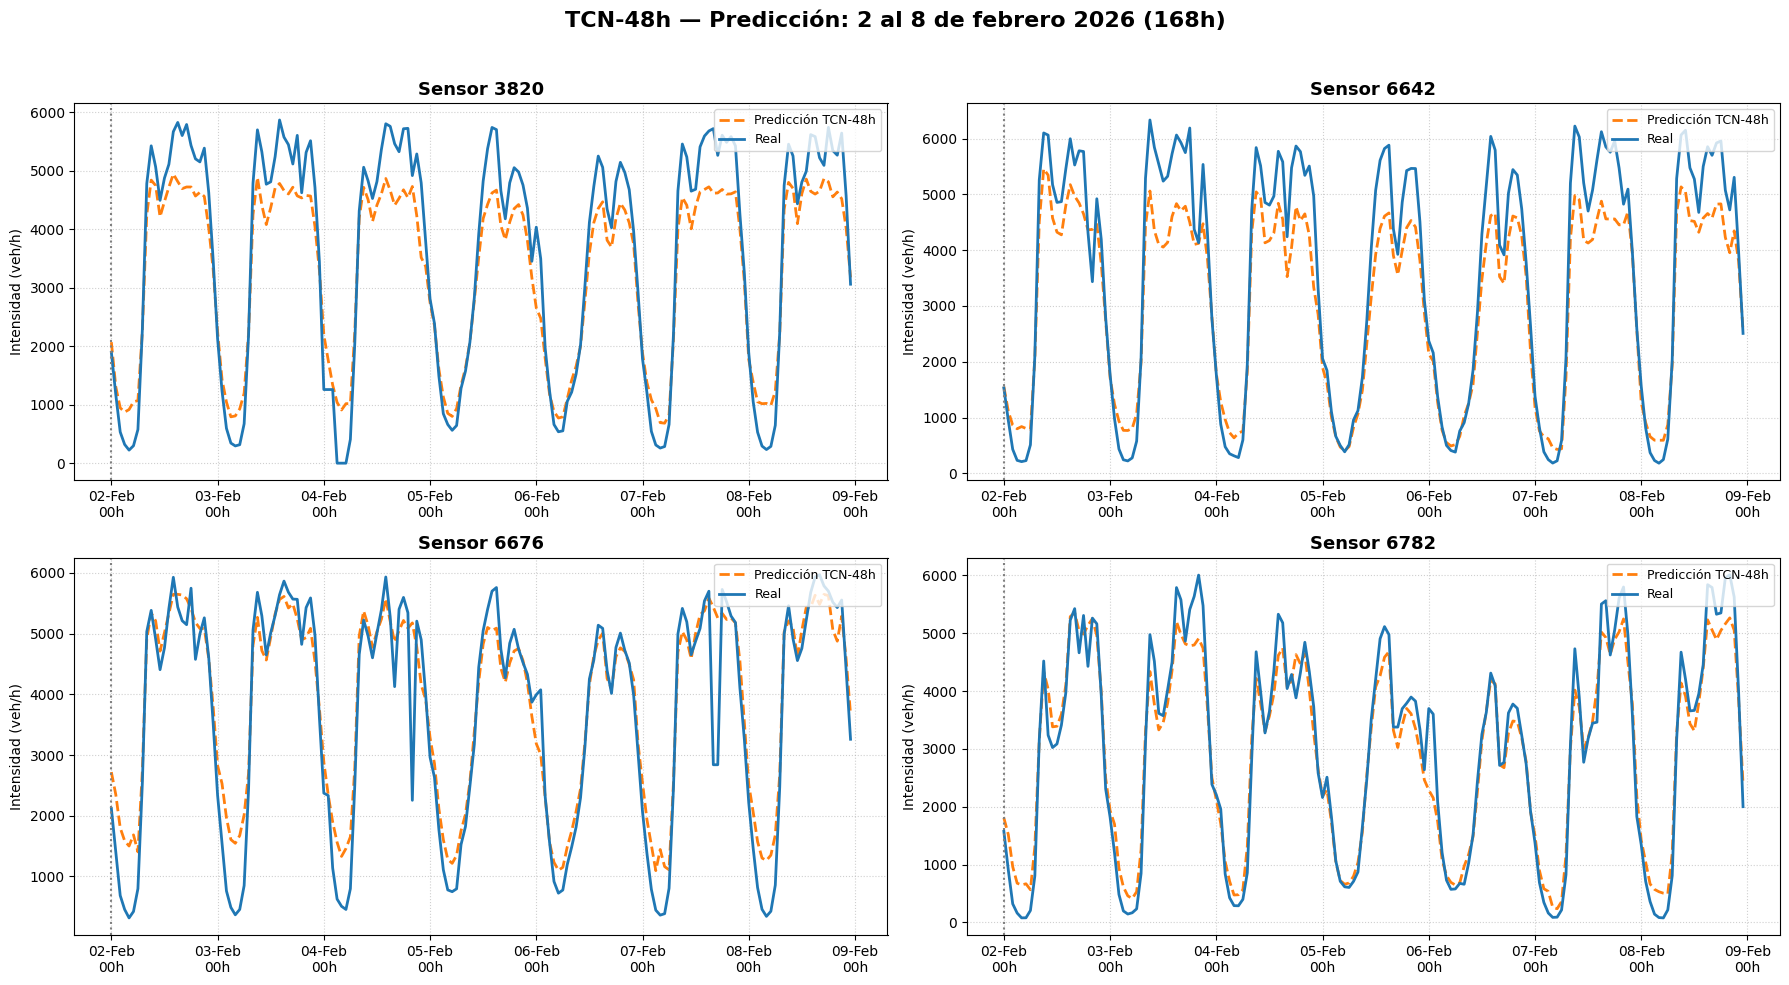

✅ Gráfica guardada en: ../data/processed/figures/grafica_tcn48_168h.png


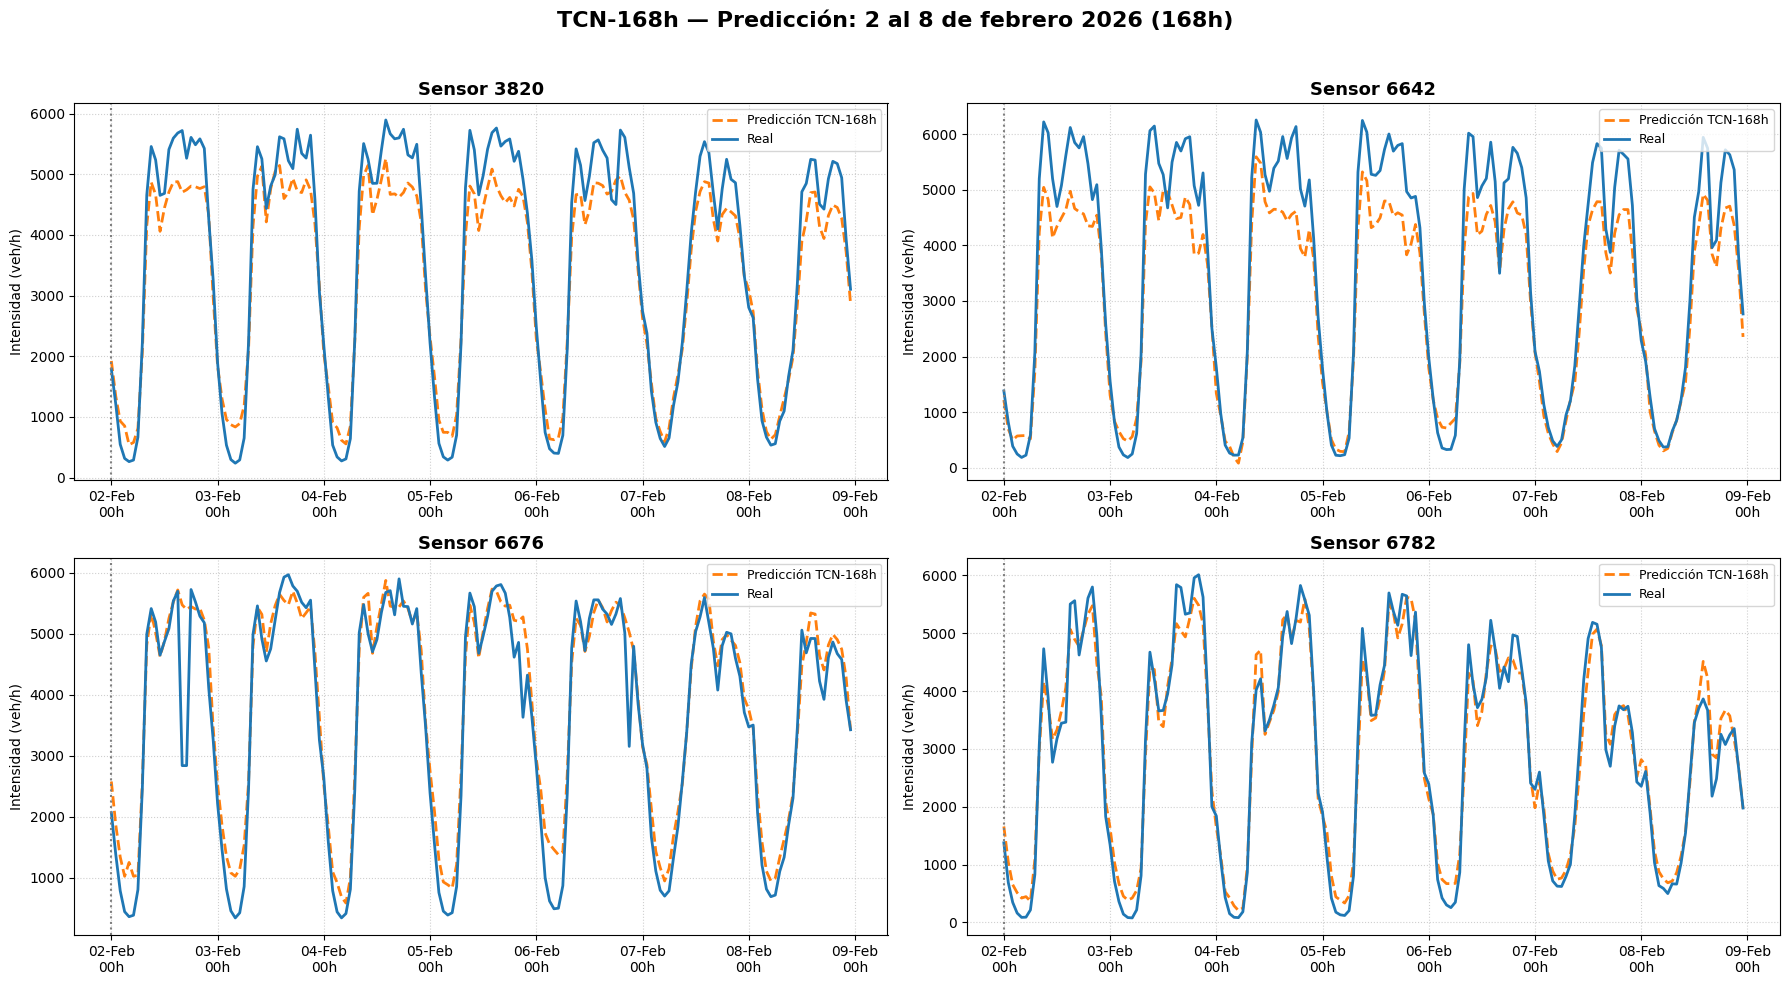

✅ Gráfica guardada en: ../data/processed/figures/grafica_tcn168_168h.png


In [17]:
# --- 9.2 GRÁFICAS SEMANA 2-8 FEBRERO 2026 (TCN) ---

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Crear carpeta de figuras si no existe
ruta_figuras = '../data/processed/figures'
os.makedirs(ruta_figuras, exist_ok=True)

semana_inicio = pd.Timestamp('2026-02-02 00:00:00')
semana_fin    = pd.Timestamp('2026-02-08 23:00:00')

# Solo generamos las dos gráficas comparables (igual que en RF y VECM)
for input_len in [48, 168]:
    
    horizonte = 168  # ← Solo horizonte 168h (igual que en los modelos anteriores)
    
    model_path = f'../../models/tcn/tcn_input{input_len}_h{horizonte}.pt'
    model = TCN(
        n_inputs=N_FEATURES,
        n_outputs=N_TARGETS,
        num_channels=MODEL_CFG['num_channels'],
        kernel_size=MODEL_CFG['kernel_size'],
        dropout=MODEL_CFG['dropout']
    ).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # Dataset del test
    ds_test = M30DatasetMulti(df_test_s, input_len, horizonte, FEATURE_COLS, INTENSITY_COLS)
    dl_test = DataLoader(ds_test, batch_size=128, shuffle=False)

    preds_norm, reals_norm = [], []
    with torch.no_grad():
        for x, y in dl_test:
            pred = model(x.to(DEVICE))
            preds_norm.append(pred.cpu().numpy())
            reals_norm.append(y.cpu().numpy())

    preds_real = np.concatenate(preds_norm) * STDS_INTEN + MEANS_INTEN
    reals_real = np.concatenate(reals_norm) * STDS_INTEN + MEANS_INTEN

    # DataFrames con índice temporal
    idx_test = df_test_s.index[ds_test.valid_indices]
    df_pred = pd.DataFrame(preds_real, index=idx_test, columns=INTENSITY_COLS)
    df_real = pd.DataFrame(reals_real, index=idx_test, columns=INTENSITY_COLS)

    # Filtrar la semana del 2 al 8 de febrero
    df_pred_semana = df_pred.loc[semana_inicio:semana_fin]
    df_real_semana = df_real.loc[semana_inicio:semana_fin]

    # Crear gráfica 2x2
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'TCN-{input_len}h — Predicción: 2 al 8 de febrero 2026 (168h)', 
                 fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, col in enumerate(INTENSITY_COLS):
        sensor_id = col.split('_')[1]
        ax = axes[i]
        ax.plot(df_pred_semana.index, df_pred_semana[col], color='#ff7f0e', 
                linestyle='--', linewidth=2, label=f'Predicción TCN-{input_len}h')
        ax.plot(df_real_semana.index, df_real_semana[col], color='#1f77b4', 
                linewidth=2, label='Real')
        ax.axvline(x=semana_inicio, color='grey', linestyle=':', linewidth=1.5)
        ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Intensidad (veh/h)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Guardar la gráfica
    nombre_archivo = f'grafica_tcn{input_len}_168h.png'
    ruta_grafica = f'{ruta_figuras}/{nombre_archivo}'
    plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Gráfica guardada en: {ruta_grafica}")

In [18]:
# --- 9.3 EXCEL COMPARATIVO TCN-48h vs TCN-168h ---

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import os
import numpy as np

ruta_carpeta = '../data/processed/models/5.TCN'
os.makedirs(ruta_carpeta, exist_ok=True)
ruta_excel = f'{ruta_carpeta}/comparativa_TCN48_vs_TCN168.xlsx'

horizontes_nombres = {1: '1_HORA', 24: '24_HORAS', 168: '168_HORAS'}
horizontes_titulos = {1: '1 HORA', 24: '24 HORAS', 168: '168 HORAS'}

sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]

def estilo_titulo(ws, fila, texto):
    ws.merge_cells(start_row=fila, start_column=1, end_row=fila, end_column=7)
    c = ws.cell(row=fila, column=1, value=texto)
    c.font      = Font(bold=True, color='FFFFFF', size=12)
    c.fill      = PatternFill('solid', fgColor='2F4F8F')
    c.alignment = Alignment(horizontal='center', vertical='center')

def aplicar_borde(cell):
    thin = Side(style='thin')
    cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = openpyxl.Workbook()
wb.remove(wb.active)

for horizonte in [1, 24, 168]:
    nombre_hoja  = horizontes_nombres[horizonte]
    titulo_hoja  = horizontes_titulos[horizonte]
    ws = wb.create_sheet(title=nombre_hoja)

    anchos = [16, 12, 12, 12, 12, 12, 12]
    for i, ancho in enumerate(anchos, 1):
        ws.column_dimensions[get_column_letter(i)].width = ancho

    # Título
    estilo_titulo(ws, 1, f'HORIZONTE: {titulo_hoja} — TCN-48h vs TCN-168h')
    ws.row_dimensions[1].height = 22

    # Cabecera modelos
    ws.merge_cells(start_row=2, start_column=2, end_row=2, end_column=4)
    ws.merge_cells(start_row=2, start_column=5, end_row=2, end_column=7)

    for col, texto, color in [(2, 'TCN-48h', '2E86AB'), (5, 'TCN-168h', 'A23B72')]:
        c = ws.cell(row=2, column=col, value=texto)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor=color)
        c.alignment = Alignment(horizontal='center', vertical='center')

    # Subcabecera métricas
    ws.cell(row=3, column=1, value='Sensor').font = Font(bold=True, color='FFFFFF', size=10)
    ws.cell(row=3, column=1).fill      = PatternFill('solid', fgColor='4472C4')
    ws.cell(row=3, column=1).alignment = Alignment(horizontal='center')

    for col, metrica in enumerate(['RMSE', 'MAE', 'R²', 'RMSE', 'MAE', 'R²'], 2):
        c = ws.cell(row=3, column=col, value=metrica)
        c.font      = Font(bold=True, color='FFFFFF', size=10)
        c.fill      = PatternFill('solid', fgColor='4472C4')
        c.alignment = Alignment(horizontal='center')

    # Datos por sensor
    colores_fila = ['FCE4D6', 'E2EFDA', 'FCE4D6', 'E2EFDA']
    for idx, sensor in enumerate(sensores):
        fila  = 4 + idx
        color = colores_fila[idx]

        m48  = resultados_test_tcn[(48,  horizonte)][sensor]
        m168 = resultados_test_tcn[(168, horizonte)][sensor]

        valores = [
            sensor,
            round(m48['RMSE'], 2), round(m48['MAE'], 2), round(m48['R²'], 4),
            round(m168['RMSE'], 2), round(m168['MAE'], 2), round(m168['R²'], 4)
        ]

        for col, val in enumerate(valores, 1):
            c = ws.cell(row=fila, column=col, value=val)
            c.fill      = PatternFill('solid', fgColor=color)
            c.font      = Font(size=10)
            c.alignment = Alignment(horizontal='center')
            aplicar_borde(c)

    # Fila PROMEDIO
    fila_prom = 8
    ws.cell(row=fila_prom, column=1, value='PROMEDIO')

    promedios = [
        np.mean([resultados_test_tcn[(48,  horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test_tcn[(48,  horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test_tcn[(48,  horizonte)][s]['R²']   for s in sensores]),
        np.mean([resultados_test_tcn[(168, horizonte)][s]['RMSE'] for s in sensores]),
        np.mean([resultados_test_tcn[(168, horizonte)][s]['MAE']  for s in sensores]),
        np.mean([resultados_test_tcn[(168, horizonte)][s]['R²']   for s in sensores]),
    ]

    for col, val in enumerate([None] + promedios, 1):
        c = ws.cell(row=fila_prom, column=col)
        if col > 1:
            c.value = round(val, 4) if col in [4, 7] else round(val, 2)
        c.font      = Font(bold=True, size=10)
        c.fill      = PatternFill('solid', fgColor='D9E1F2')
        c.alignment = Alignment(horizontal='center')
        aplicar_borde(c)

wb.save(ruta_excel)
print(f"✅ Excel guardado en: {ruta_excel}")

✅ Excel guardado en: ../data/processed/models/5.TCN/comparativa_TCN48_vs_TCN168.xlsx


## 9. Conclusiones del Modelado TCN

*(Completar tras ejecutar el notebook con los resultados obtenidos)*

Puntos clave a desarrollar:

1. **Rendimiento por horizonte**: comparar MAE/RMSE a 1h, 24h y 168h frente al VAR y el VECM.
2. **Efecto de la ventana de entrada**: contrastar los resultados con `input_len=48h` vs `input_len=168h`.
3. **Degradación con el horizonte**: analizar si el TCN, gracias al *direct forecasting*, mitiga la acumulación de error observada en los modelos autorregresivos (VAR/VECM) a 168h.
4. **Capacidad de capturar estacionalidad**: valorar si el modelo reproduce correctamente los ciclos diarios y semanales de tráfico, especialmente con `input_len=168h`.